## HW 1: Sinusoids, Functions, Additive Synthesis (15 points)
For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from IPython.display import Audio
from scipy.io.wavfile import read

### Question 1 - Sinusoids (3 points)
Define the function, **genSine(f, ...)** that construct a sinusoid at frequency `f`.
The arguments should include:  
* amplitude, with default value of 1 (float)
* sample rate, with default value of 44.1kHz (float)
* time in seconds, with default value of 1 (float)
* phase offset, with default value of 0 (float)
    
and will return the numpy array containing the sinusoidal waveform.

Your function must check for appropriate input and handle any errors.
    

In [ ]:
def genSine(frequency, amplitude=1, samplingRate=44100, duration=1, phaseOffset=0):
    frequency = float(frequency)
    amplitude = float(amplitude)
    samplingRate = int(samplingRate)
    duration = float(duration)
    phaseOffset = float(phaseOffset)

    if phaseOffset > 2*np.pi:
        phaseOffset = 2*np.pi
        print("Scaled phaseOffset to correct input range.")
    if phaseOffset < 0:
        phaseOffset = 0
        print("Scaled phaseOffset to correct input range.")
    if samplingRate <= 0:
        print("Sampling rate must be a postive number")
        return
    if duration <= 0:
        print("Duration must be a postive number")
        return
    if frequency*2 >= samplingRate:
        print("Sampling rate is to low for frequency. Aliasing is occuring.")

    t = np.arange(0, duration, 1/samplingRate)
    return np.cos(2*np.pi * frequency * t + phaseOffset) * amplitude

### Question 2 - Classical Waveform (5 points)
Define a function, **genWave(freq, t, numHarms=None, A=1, phi=0, fs=44100)**, that will create one of the fundamental waveforms (saw, triangle, or square) built from the combination of sinusoids at integer multiples of a fundamental frequency.  The arguments passed will be as follows:

* freq will be the frequency in Hz (int or float).
* t will be the length of time in seconds (int or float).
* numHarms will be the number of harmonics used. If no value is given (NoneType), you should create the maximum harmonics possible given the sampling rate

The function should return a numpy array. **You may not use existing waveform functions such as those in the `scipy` library.**

Your function must check for appropriate input and handle any errors.

Try to make your function as efficient as you can, but we will not take points off for a long run time. Be mindful by using NumPy functions rather than direct iteration.

*Hint: your function should use your genSine function

**Bonus: Expand this function to create any of the classical waveforms with a new argument "type" specifying which to build.

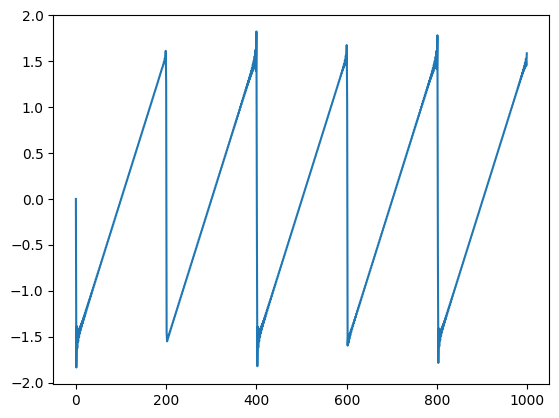

In [34]:
from abc import ABC, abstractmethod
import math

class Wave(ABC):
    @abstractmethod
    def getHarmonicRatio():
        pass
    def getHarmonicDecay(currentPartial):
        pass
class TriangleWave(Wave):
    @staticmethod
    def getHarmonicRatio():
        return 2
    @staticmethod
    def getHarmonicDecay(currentPartial):
        return 1/(currentPartial ** 2)
class SawWave(Wave):
    @staticmethod
    def getHarmonicRatio():
        return 1
    @staticmethod
    def getHarmonicDecay(currentPartial):
        return 1/(currentPartial)
class SquareWave(Wave):
    @staticmethod
    def getHarmonicRatio():
        return 2
    @staticmethod
    def getHarmonicDecay(currentPartial):
        return 1/(currentPartial)

def genWave(freq, waveType, t, numHarms=None, A=1, phi=0, fs=44100):
    freq = float(freq)
    A = float(A)
    phi = float(phi)
    fs = int(fs)
    t = int(t*100) ##I don't want to deal with mismatching array lengths. We are truncating to two decimal places.
    t /= 100
    numHarms = 2**16 if numHarms == None else numHarms
    numHarms = int(numHarms)

    returnWave = np.zeros(int(fs*t))
    valueTable = np.arange(0, t, 1/fs)

    if issubclass(type(waveType), Wave) == False:
        print("waveType not a valid input.")
        return
    if phi > 2*np.pi:
        phaseOffset = 2*np.pi
        print("Scaled phaseOffset to correct input range.")
    if phi < 0:
        phaseOffset = 0
        print("Scaled phaseOffset to correct input range.")
    if fs <= 0:
        print("Sampling rate must be a postive number")
        return
    if t <= 0:
        print("Duration must be a postive number")
        return
    if freq*2 >= fs:
        print("Sampling rate is to low for frequency. Aliasing is occuring.")

    for i in range(0, numHarms, 1):
        ithHarmonic = 1 + (i * waveType.getHarmonicRatio())
        ithFreq = freq * ithHarmonic
        if abs(ithFreq*2) >= fs:
            break
        ithA = waveType.getHarmonicDecay(ithHarmonic)
        ithWave = np.sin(2*np.pi * ithFreq * valueTable + phi) * ithA
        returnWave += ithWave
    
    return returnWave

sawTest = genWave(-220, SawWave(), 1) ##Proably smarter to use enums or something else instead of classes but the sunk cost fallacy set in.
plt.plot(sawTest[:1000])
Audio(sawTest, rate=44100)

### Question 3 - Arpeggio (4 points)

Define the function arpegiateFreq(freq, dur), that will create a major scale arpeggio of a given frequency for a given length using your genWave() function. The arguments passed will be as follows:
* freq will be the starting/fundamental frequency in Hz (int or float)
* dur will be the length of time in seconds (int or float)

Reminder: a major scale arpeggio is built from the root, major third, and perfect 5th. You should divide the duration evenly amongst the three notes. 

The function should return a numpy array.

*Hint: your function will use the function(s) you just wrote*

Your function must check for appropriate input and handle any errors

**Bonus: Create a new function called arpegiateNote(scale, dur). Instead of the second input being frequency in Hz, the function should receive a note name like 'C'. You will need to convert this note to frequency. If you want to go the extra mile, make it case sensitive, such that an uppercase 'C' yields a C major arpeggio and lowercase 'c' yields a c minor arpeggio.

In [37]:
def arpegiateFreq(freq, dur):
    if dur <= 0:
        print("Duration must be a postive number")
        return
    returnWave = genWave(freq, SquareWave(), dur/3)
    returnWave = np.concatenate((returnWave, genWave(freq*1.26, SquareWave(), dur/3)))
    returnWave = np.concatenate((returnWave, genWave(freq*1.5, SquareWave(), dur/3)))
    return returnWave

test = arpegiateFreq(440, 3)
Audio(test, rate=44100)
    

## Error handling tips and edge cases
What should happen if the frequency inputs to our functions would generate frequncies above Nyquist?

What should happen if our time inputs are negative? Or are 0?

What should happen if our frequencies are negative? Or are 0?

You should account for actual coding errors and errors that conceptually do not make sense.

### Section 4 - Using functions and graphing (3 points)
Create a 2 second F major arpeggio in an array named 'myArp'. Play back your audio.

Remove every 4th sample of 'myArp', save as a new array, 'skipped, and play back your audio. What happened to the audio?

Create a 2 Bb major arpeggio in an array named 'myArp2'. Play back your audio

Reverse 'myArp2' and save as a new array, 'reverse'. Play back your audio

Graph your 4 arrays on top of one another. Make sure to label the axis and plot against time. 

Create another graph, but this time only plot the first "note" of each array

In [38]:
myArp = arpegiateFreq(349.2, 3)
Audio(myArp, rate=44100)

In [ ]:
skipped = myArp[::4]
Audio(skipped, rate=44100)
#Audio transposed up 2 octaves

In [41]:
myArp2 = arpegiateFreq(466.2, 3)
Audio(myArp2, rate=44100)

In [44]:
reverse = np.flip(myArp2)
Audio(reverse, rate=44100)

Text(0, 0.5, 'Amplitude')

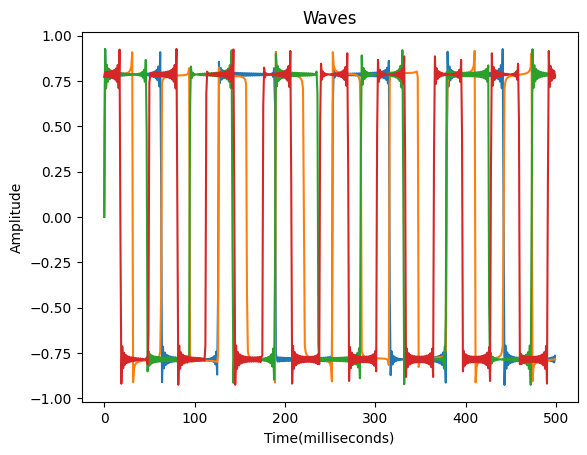

In [49]:
time = np.arange(0, 500, 1)
plt.plot(time, myArp[0:500], time, skipped[0:500], time, myArp2[0:500], time, reverse[0:500])
plt.title("Waves")
plt.xlabel("Time(milliseconds)")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

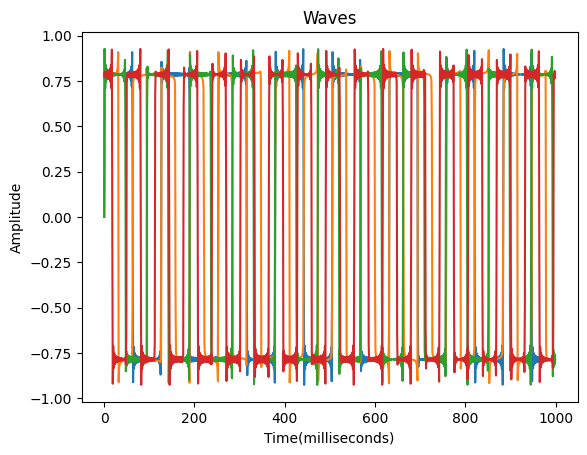

In [51]:
time = np.arange(0, 1000, 1)
plt.plot(time, myArp[0:1000], time, skipped[0:1000], time, myArp2[0:1000], time, reverse[0:1000])
plt.title("Waves")
plt.xlabel("Time(milliseconds)")
plt.ylabel("Amplitude")

### GenAI Usage Statement (if applicable)